In [1]:
import pandas as pd
file_path = "/Users/renoodle/Library/Mobile Documents/com~apple~CloudDocs/2019_2025_Master.csv"
sales = pd.read_csv(file_path)
sales.head()

,Month,Date,Day,Year
0,January,1/1/19,Tuesday,3265.69
1,January,1/2/19,Wednesday,6727.80
2,January,1/3/19,Thursday,6261.28
3,January,1/4/19,Friday,6445.43
4,January,1/5/19,Saturday,8538.66


In [2]:
sales.shape

(2555, 4)

In [3]:
sales.columns

Index(['Month', 'Date', 'Day', 'Year'], dtype='object')

In [4]:
sales.tail()

,Month,Date,Day,Year
2550,December,12/27/25,Thursday,11462.6
2551,December,12/28/25,Friday,1598.4
2552,December,12/29/25,Saturday,9316.6
2553,December,12/30/25,Sunday,9753.2
2554,December,12/31/25,Monday,20128.0


In [5]:
sales = sales.rename(columns={"Year": "Sales"})

In [8]:
sales["Date"] = pd.to_datetime(sales["Date"])
sales["Year"] = sales["Date"].dt.year

In [9]:
sales.columns

Index(['Month', 'Date', 'Day', 'Sales', 'Year'], dtype='object')

In [ ]:
# Analyzed 6 year of retail sales data (2019-2025) using Python.
# Transformed raw CSV data into a structured dataset and calculated year-over-year performance.
# Identified a significant decline in 2020 (-42.99%), followed by a strong recovery in 2021 (+64.97%).
# a gradual decline from 2022-2024, and and a rebound in 2025 (+42.52%).

In [11]:
yearly_sales = sales.groupby("Year")["Sales"].sum().sort_index()
yoy = yearly_sales.to_frame(name="Total_Sales")
yoy["YoY_$"] = yoy["Total_Sales"].diff()
yoy["YoY_%"] = yoy["Total_Sales"].pct_change() * 100
yoy

,Total_Sales,YoY_$,YoY_%
Year,,,
2019,3732464.47,NaN,NaN
2020,2127951.24,-1604513.23,-42.988038
2021,3510395.49,1382444.25,64.965974
2022,3089087.92,-421307.57,-12.001712
2023,2688419.57,-400668.35,-12.970442
2024,2471812.85,-216606.72,-8.057028
2025,3522710.80,1050897.95,42.515272


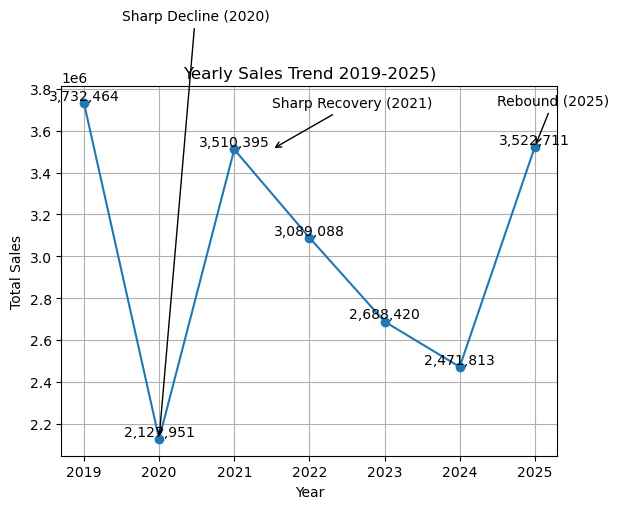

In [18]:
import matplotlib.pyplot as plt
plt.figure()

# Plot line
yoy["Total_Sales"].plot(marker='o')

# Titles
plt.title("Yearly Sales Trend 2019-2025)")
plt.xlabel("Year")
plt.ylabel("Total Sales")

# Add labels points
for year, value in yoy["Total_Sales"].items():
    plt.text(year, value, f"{value:,.0f}", ha='center', va='bottom')
    
# Add insight annotations
plt.annotate("Sharp Decline (2020)",
            xy=(2020, yoy.loc[2020, "Total_Sales"]),
             xytext=(2019.5, yoy.loc[2020, "Total_Sales"] + 2000000),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("Sharp Recovery (2021)",
            xy=(2021.5, yoy.loc[2021, "Total_Sales"]),
             xytext=(2021.5, yoy.loc[2021, "Total_Sales"] + 200000),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("Rebound (2025)",
            xy=(2025, yoy.loc[2025, "Total_Sales"]),
            xytext=(2024.5, yoy.loc[2025, "Total_Sales"] + 200000),
            arrowprops=dict(arrowstyle="->"))

plt.grid()
plt.show()

In [19]:
# Insight:
# The data show a clear disruption and recovery cycle. Sales were strong in 2019 (pre-pandemic), declined 
# sharply in 2020, then rebounded significantly in 2021. From 2022-2024, sales gradually declined, 
# suggesting a normalization period post-recovery. In 2025, sales show a strong rebound, indicating 
# renewed growth momentum.

In [20]:
plt.savefig("yearly_dales_trend.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>